In [1]:
import atomic_units as au
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output
import matplotlib.pyplot as plt
from quantum_toolkit import potentials as pots
import quantum_toolkit as quat
import scipy.sparse as sparse
import numpy as np
import time

display(HTML("""
<style>
.output_scroll {overflow: visible !important; max-height: none !important;}
.potparam-row > .widget-label { min-width: 90px; }
.potparam-row > .widget-label, .potparam-row > .widget-inline-hbox { margin-right: 8px; }
</style>
"""))

# --- Globális paraméterek ---
hb=1.0
m0=8.8
k0=2.3
e0=3.4
unit_sys = au.AtomicUnitSystem(xh=hb, xe=e0, xm=m0, xk=k0)

# --- Unit system widgetek deklarációja (KORÁBBRA MOZGATVA) ---
hbar_widget = widgets.FloatText(description="hbar:", value=unit_sys.hb)
m0_widget = widgets.FloatText(description="m0:", value=unit_sys.me)
kappa0_widget = widgets.FloatText(description="kappa0:", value=unit_sys.k0)
e0_widget = widgets.FloatText(description="e0:", value=unit_sys.e0)

uxgrid_num = 4*1024
uxgrid_dx = 0.025
uxgrid_width = uxgrid_num * uxgrid_dx
uxgrid = np.arange(-uxgrid_width/2, uxgrid_width/2, uxgrid_dx)

# --- Itt legyen a dx_widget definíció ---
dx_widget = widgets.FloatText(description="Lépésköz:", value=uxgrid_dx, min=1e-10)

# Paraméter widgetek
wallwidth_widget = widgets.FloatText(value=3.0, description="wallwidth [nm]")
wallheight_widget = widgets.FloatText(value=1.0, description="wallheight [eV]")
wallrise_widget = widgets.FloatText(value=1.0, description="wallrise [nm]")
wellwidth_widget = widgets.FloatText(value=10.0, description="wellwidth [nm]")
welldepth_widget = widgets.FloatText(value=1.0, description="welldepth [eV]")
wellfall_widget = widgets.FloatText(value=1.0, description="wellfall [nm]")

# Új widgetek a szuperrácshoz
num_cells_widget = widgets.IntText(value=1, min=1, description="Number of cells:", style={'description_width': 'initial'})
cell_spacing_widget = widgets.FloatText(value=0.0, description="Cell spacing [nm]:", style={'description_width': 'initial'})

def get_modelpot():
    wallwidth = wallwidth_widget.value * unit_sys.convert_length_from('nm')
    wallheight = wallheight_widget.value * unit_sys.convert_energy_from('eV')
    wallrise = wallrise_widget.value
    wellwidth = wellwidth_widget.value * unit_sys.convert_length_from('nm')
    welldepth = welldepth_widget.value * unit_sys.convert_energy_from('eV')
    wellfall = wellfall_widget.value
    num_cells = num_cells_widget.value
    cell_spacing = cell_spacing_widget.value * unit_sys.convert_length_from('nm')

    # Egy cella szélessége (2*fal + gödör + spacing)
    cell_length_nm = 2*wallwidth_widget.value + wellwidth_widget.value + cell_spacing_widget.value
    cell_length_unit = cell_length_nm * unit_sys.convert_length_from('nm')

    pot = np.zeros_like(uxgrid)
    for i in range(num_cells):
        offset = (i - (num_cells-1)/2) * cell_length_unit
        cell_pot = pots.SmoothStackPotential(
            uxgrid - offset,
            wallwidth=wallwidth,
            wallheight=wallheight,
            welldepth=welldepth,
            wellwidth=wellwidth,
            wallrise=wallrise,
            wellfall=wellfall
        )(0)
        pot += cell_pot #pot = np.maximum(pot, cell_pot)
    return lambda t=0: pot

# --- Potential tab ---
plot_unit_toggle = widgets.ToggleButtons(
    options=[('unit_sys', False), ('nm/eV', True)],
    value=True,
    description='Plot units:',
    style={'description_width': 'initial'}
)
plot_margin_widget = widgets.FloatText(value=10.0, layout=widgets.Layout(width='70px'))
plot_margin_label = widgets.Label("nm")
pot_output = widgets.Output()
pot_output.layout = widgets.Layout(overflow='visible', max_height='none')

def plot_potential(change=None):
    with pot_output:
        clear_output(wait=True)
        modelpot = get_modelpot()
        plot_margin_nm = plot_margin_widget.value
        total_width_nm = num_cells_widget.value * (2*wallwidth_widget.value + wellwidth_widget.value + cell_spacing_widget.value)
        x_min_nm = -0.5 * total_width_nm - plot_margin_nm
        x_max_nm = 0.5 * total_width_nm + plot_margin_nm

        if plot_unit_toggle.value:
            x_plot = uxgrid * unit_sys.length_unit.to('nm').magnitude
            y = modelpot(0) * unit_sys.energy_unit.to('eV').magnitude
            x_min = x_min_nm
            x_max = x_max_nm
            xlabel = "x [nm]"
            ylabel = "Potenciál [eV]"
        else:
            x_plot = uxgrid
            x_min = (x_min_nm / unit_sys.length_unit.to('nm').magnitude)
            x_max = (x_max_nm / unit_sys.length_unit.to('nm').magnitude)
            xlabel = "x [unit_sys]"
            ylabel = "Potenciál [unit_sys]"
            y = modelpot(0)

        plt.figure(figsize=(7, 3))
        plt.plot(x_plot, y)
        plt.xlabel(xlabel)
        plt.ylabel(ylabel)
        plt.grid()
        plt.xlim([x_min, x_max])
        plt.tight_layout()
        plt.show()

for w in [
    wallwidth_widget, wallheight_widget, wallrise_widget,
    wellwidth_widget, welldepth_widget, wellfall_widget,
    plot_unit_toggle, plot_margin_widget,
    num_cells_widget, cell_spacing_widget
]:
    w.observe(plot_potential, names='value')
plot_potential()

potential_tab = widgets.VBox([
    widgets.Label("SmoothStackPotential parameters"),
    plot_unit_toggle,
    widgets.HBox([widgets.Label("Plot margin:"), plot_margin_widget, plot_margin_label]),
    num_cells_widget,
    cell_spacing_widget,
    wallwidth_widget, wallheight_widget, wallrise_widget,
    wellwidth_widget, welldepth_widget, wellfall_widget,
    pot_output
])

# --- Eigenstate tab ---
eigen_output = widgets.Output()

num_eigen_widget = widgets.IntText(
    value=6, min=1, description="Number of eigenvalues to compute:",
    style={'description_width': 'initial'}
)
num_plot_widget = widgets.IntText(
    value=6, min=1, description="Show on plot:",
    style={'description_width': 'initial'}
)

eigen_unit_toggle = widgets.ToggleButtons(
    options=[('unit_sys', False), ('nm/eV', True)],
    value=True,
    description='Plot units:',
    style={'description_width': 'initial'}
)

# Tároljuk az utolsó eredményt
_last_eigenvalues = None
_last_eigenvectors = None
_last_x_plot = None
_last_y_pot = None
_last_eigenvalues_plot = None
_last_xlabel = None
_last_ylabel = None

def compute_eigenstates(_=None):
    global _last_eigenvalues, _last_eigenvectors, _last_x_plot, _last_y_pot, _last_eigenvalues_plot, _last_xlabel, _last_ylabel
    with eigen_output:
        clear_output(wait=True)
        print("Eigenstate calculation started...")
        import time
        start_time = time.time()
        wallwidth = wallwidth_widget.value * unit_sys.convert_length_from('nm')
        wallheight = wallheight_widget.value * unit_sys.convert_energy_from('eV')
        welldepth = welldepth_widget.value * unit_sys.convert_energy_from('eV')
        wellwidth = wellwidth_widget.value * unit_sys.convert_length_from('nm')
        wallrise = wallrise_widget.value
        wellfall = wellfall_widget.value
        modelpot = get_modelpot()
        zeropot = pots.ZeroPotential(uxgrid)
        ham_static = quat.HamiltonOperator(
            uxgrid,
            hbar=unit_sys.hb,
            me=unit_sys.me,
            charge=unit_sys.e0,
            scalarpot=modelpot,
            vectorpot=zeropot
        )
        num_eigen = max(1, int(num_eigen_widget.value))
        num_plot = max(1, int(num_plot_widget.value))
        print(f"Diagonalization in progress for {num_eigen} eigenvalues, please wait...")
        eigenvalues, eigenvectors = sparse.linalg.eigsh(ham_static(0), num_eigen, which='SR')
        elapsed = time.time() - start_time

        # Mértékegység választás
        if eigen_unit_toggle.value:
            x_plot = uxgrid * unit_sys.length_unit.to('nm').magnitude
            y_pot = modelpot(0) * unit_sys.energy_unit.to('eV').magnitude
            eigenvalues_plot = eigenvalues * unit_sys.energy_unit.to('eV').magnitude
            xlabel = "x [nm]"
            ylabel = "Energy [eV]"
        else:
            x_plot = uxgrid
            y_pot = modelpot(0)
            eigenvalues_plot = eigenvalues
            xlabel = "x [unit_sys]"
            ylabel = "Energy [unit_sys]"

        # Eredmények eltárolása
        _last_eigenvalues = eigenvalues
        _last_eigenvectors = eigenvectors
        _last_x_plot = x_plot
        _last_y_pot = y_pot
        _last_eigenvalues_plot = eigenvalues_plot
        _last_xlabel = xlabel
        _last_ylabel = ylabel

        print(f"Calculation finished in {elapsed:.1f} seconds.")
        print(f"Eigenvalues:", eigenvalues_plot[:num_plot])
        plot_eigenstates(num_plot)

def plot_eigenstates(num_plot=None):
    with eigen_output:
        clear_output(wait=True)
        if _last_eigenvalues is None:
            print("No eigenstate data. Please compute eigenstates first.")
            return
        if num_plot is None:
            num_plot = max(1, int(num_plot_widget.value))
        x_plot = _last_x_plot
        y_pot = _last_y_pot
        eigenvalues_plot = _last_eigenvalues_plot
        eigenvectors = _last_eigenvectors
        xlabel = _last_xlabel
        ylabel = _last_ylabel
        num_eigen = len(_last_eigenvalues)

        print(f"Eigenvalues:", eigenvalues_plot[:num_plot])

        plt.figure(figsize=(8, 4))
        plt.plot(x_plot, y_pot, label="Potential")
        for eval, evec in zip(eigenvalues_plot[:num_plot], np.transpose(eigenvectors)[:num_plot]):
            plt.plot(x_plot, eval * np.ones_like(x_plot), "--", label=f"E={eval:.2e}")
        plt.xlabel(xlabel)
        plt.xlim([x_plot[0], x_plot[-1]])
        plt.legend(loc='upper right')
        plt.grid()
        plt.title("Eigenstates and Potential")
        plt.show()

        plt.figure()
        plt.scatter(np.arange(num_eigen)[:num_plot], eigenvalues_plot[:num_plot], marker='o', color='red')
        plt.xlabel("State index")
        plt.ylabel(ylabel)
        plt.title("Eigenvalues")
        plt.grid()
        plt.show()

eigen_button = widgets.Button(description="Compute eigenstates", button_style='primary')
eigen_button.on_click(compute_eigenstates)
num_plot_widget.observe(lambda change: plot_eigenstates(), names='value')
eigen_unit_toggle.observe(lambda change: plot_eigenstates(), names='value')

# Foton hullámhossz és energia mezők
photon_wavelength_widget = widgets.FloatText(
    value=800.0, description="Photon wavelength [nm]:", style={'description_width': 'initial'}
)
photon_energy_widget = widgets.Label(value="Photon energy: --- eV")

def update_photon_energy(change=None):
    # E = hc/λ, ahol h = 4.135667696e-15 eV·s, c = 299792458 m/s, λ nm-ben
    h = 4.135667696e-15  # eV·s
    c = 299792458  # m/s
    try:
        wavelength_nm = photon_wavelength_widget.value
        wavelength_m = wavelength_nm * 1e-9
        energy_eV = h * c / wavelength_m
        photon_energy_widget.value = f"Photon energy: {energy_eV:.3f} eV"
    except Exception:
        photon_energy_widget.value = "Photon energy: --- eV"

photon_wavelength_widget.observe(update_photon_energy, names='value')
update_photon_energy()

eigen_tab = widgets.VBox([
    widgets.Label("Eigenstate calculation"),
    eigen_unit_toggle,
    num_eigen_widget,
    num_plot_widget,
    photon_wavelength_widget,
    photon_energy_widget,
    widgets.HBox([eigen_button]),
    eigen_output
])

# --- Dispersion tab ---
# dispersion = None  # Ezt töröljük, helyette globális változóként kezeljük

# Dispersion objektum automatikus létrehozása a kezdeti paraméterekkel
dispersion = None
def update_dispersion(*args):
    global dispersion
    import quantum_toolkit as quat
    try:
        dispersion = quat.CosineDispersion(
            dx_widget.value,
            hbar=unit_sys.hb,
            mass=unit_sys.me
        )
    except Exception as e:
        print("Hiba a dispersion létrehozásakor:", e)
update_dispersion()  # Induláskor egyszer lefut

# Frissítés, ha dx_widget vagy unit_sys paraméterek változnak
dx_widget.observe(lambda change: update_dispersion(), names='value')
hbar_widget.observe(lambda change: update_dispersion(), names='value')
m0_widget.observe(lambda change: update_dispersion(), names='value')

dispersion_output = widgets.Output()

def create_dispersion(_=None):
    with dispersion_output:
        clear_output(wait=True)
        update_dispersion()
        print("Dispersion objektum létrehozva/frissítve:")
        print("dx =", dx_widget.value)
        print("hbar =", unit_sys.hb)
        print("mass =", unit_sys.me)

dispersion_button = widgets.Button(description="Create dispersion", button_style='primary')
dispersion_button.on_click(create_dispersion)
dispersion_tab = widgets.VBox([
    widgets.Label("Dispersion objektum létrehozása/frissítése az aktuális beállításokkal"),
    dispersion_button,
    dispersion_output
])

# --- Egyéb tabok (unit, grid, scatter) ---
unit_tab = widgets.VBox([
    widgets.Label("Atomic Unit system"),
    hbar_widget,
    m0_widget,
    kappa0_widget,
    e0_widget
])
points_widget = widgets.IntText(description="Pontok száma:", value=uxgrid_num, min=1)
dx_widget = widgets.FloatText(description="Lépésköz:", value=uxgrid_dx, min=1e-10)
width_widget = widgets.Label(value="Teljes hossz: ---")
def update_width(*args):
    try:
        n = points_widget.value
        dx = dx_widget.value
        width = n * dx * unit_sys.length_unit.to('nm')
        width_widget.value = f"Teljes hossz: {width:.4f}"
    except Exception:
        width_widget.value = "Teljes hossz: ---"
points_widget.observe(update_width, names='value')
dx_widget.observe(update_width, names='value')
update_width()
grid_tab = widgets.VBox([
    widgets.Label("Grid setup"),
    points_widget,
    dx_widget,
    width_widget
])

# --- Scatter tab számítás és gomb összekötése ---
scatter_output = widgets.Output()

def compute_scatter(_=None):
    with scatter_output:
        clear_output(wait=True)
        t_vals = []
        r_vals = []

        # Paraméterek (ezeket később widgetekből is lehet olvasni)
        energy_min = 5.4
        energy_max = 5.6

        energy_min_in_unit_sys = energy_min * unit_sys.convert_energy_from('eV')
        energy_max_in_unit_sys = energy_max * unit_sys.convert_energy_from('eV')

        k_min = dispersion.energy(energy_min_in_unit_sys)
        k_max = dispersion.energy(energy_max_in_unit_sys)

        k_vals = np.linspace(k_min, k_max, 11)
        print("k_min, k_max, k_vals:", k_min, k_max, k_vals)

        e_vals = []
        quasiparticles_pk = []
        quasiparticles_mk = []

        # Potenciál és Hamilton-operátor
        modelpot = get_modelpot()
        zeropot = pots.ZeroPotential(uxgrid)
        ham_static = quat.HamiltonOperator(
            uxgrid,
            hbar=unit_sys.hb,
            me=unit_sys.me,
            charge=unit_sys.e0,
            scalarpot=modelpot,
            vectorpot=zeropot
        )

        for k in k_vals:
            kin = k
            ein = dispersion.energy(k)
            e_vals.append(ein)

            qp_pk, qp_mk = quat.quasiparticles_at_given_energy(ein, kin, ham_static)
            quasiparticles_pk.append(qp_pk)
            quasiparticles_mk.append(qp_mk)

            t_vals.append(qp_pk['transmission'])
            r_vals.append(qp_pk['reflection'])

            print("k:", kin, "T:", qp_pk['transmission'], "R:", qp_pk['reflection'])

        # Eredmények ábrázolása
        plt.figure()
        plt.plot(k_vals, t_vals, "-o", label="T")
        plt.plot(k_vals, r_vals, "-o", label="R")
        plt.xlabel("k [arb. u.]")
        plt.legend()
        plt.grid()
        plt.title("Transmission/Reflection vs k")
        plt.show()

        plt.figure()
        plt.plot(e_vals, t_vals, "-o", label="T")
        plt.plot(e_vals, r_vals, "-o", label="R")
        plt.xlabel("electron energy [arb. u.]")
        plt.legend()
        plt.grid()
        plt.title("Transmission/Reflection vs energy")
        plt.show()

scatter_button = widgets.Button(description="Compute", button_style='primary')
scatter_button.on_click(compute_scatter)
scatter_tab = widgets.VBox([
    widgets.Label("Scatter"),
    scatter_button,
    scatter_output
])

# --- Dispersion tab interaktív ábra ---
disp_grid_mode = widgets.Dropdown(
    options=['unified in energy', 'unified in k'],
    value='unified in k',
    description='Grid type:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='180px')
)
disp_energy_min = widgets.FloatText(
    value=0.02,
    description='min:',
    min=0.0,  # Csak pozitív érték engedélyezett
    style={'description_width': '60px'},
    layout=widgets.Layout(width='180px')
)
disp_energy_max = widgets.FloatText(
    value=1.2,
    description='max:',
    min=0.0,  # Csak pozitív érték engedélyezett
    style={'description_width': '60px'},
    layout=widgets.Layout(width='180px')
)
disp_number_of_points = widgets.IntText(
    value=50,
    min=2,
    description='Num. of pts.:',
    style={'description_width': '60px'},
    layout=widgets.Layout(width='180px')
)

def update_dispersion_tab_plot(grid_mode, energy_min, energy_max, num):
    import matplotlib.pyplot as plt
    e_min = energy_min
    e_max = energy_max
    if dispersion is None:
        print("A dispersion objektum nincs inicializálva. Kérlek, hozd létre először a 'Create dispersion' gombbal!")
        return
    if grid_mode == 'unified in k':
        k_min = dispersion.wavenumber(e_min)
        k_max = dispersion.wavenumber(e_max)
        kvals, dk = np.linspace(k_min, k_max, num, retstep=True)
        evals = dispersion.energy(kvals)
        plt.plot(kvals, evals, 'o-', label='k-grid')
        plt.xlabel("k [arb. u.]")
        plt.ylabel("energy [arb. u.]")
        plt.title("Equidistant in k")
    else:
        evals = np.linspace(e_min, e_max, num)
        kvals = dispersion.wavenumber(evals)
        plt.plot(kvals, evals, 'o-', label='energy-grid')
        plt.xlabel("k [arb. u.]")
        plt.ylabel("energy [arb. u.]")
        plt.title("Equidistant in energy")
    plt.grid()
    plt.legend()
    plt.show()

disp_wg_plot = widgets.interactive_output(
    update_dispersion_tab_plot,
    {
        'grid_mode': disp_grid_mode,
        'energy_min': disp_energy_min,
        'energy_max': disp_energy_max,
        'num': disp_number_of_points
    }
)

dispersion_tab = widgets.VBox([
    widgets.Label("Dispersion grid setup"),
    disp_grid_mode,
    disp_energy_min,
    disp_energy_max,
    disp_number_of_points,
    disp_wg_plot
])

# --- Tabs összerakása ---
tabs = widgets.Tab(children=[unit_tab, grid_tab, potential_tab, eigen_tab, dispersion_tab, scatter_tab])
tabs.set_title(0, 'Unit system')
tabs.set_title(1, 'Grid')
tabs.set_title(2, 'Potential')
tabs.set_title(3, 'Eigenstates')
tabs.set_title(4, 'Dispersion')
tabs.set_title(5, 'Scatter')
display(tabs)

In [3]:
import quantum_toolkit as quat
# Create a dispersion object with the specified grid spacing
dispersion=quat.Dispersion(uxgrid_dx, hbar = unit_sys.hb,\
                            mass = unit_sys.me)

AttributeError: module 'quantum_toolkit' has no attribute 'Dispersion'

#Paraméter szett csak az elejére

potenciál magassága max pár eV GaN és arany vagy amit a Vaclav használt
geometriát is kb realisztikusra
potenciál gát magassága legyen 1 vagy 2 eV

Ha ez nem mutat semmit akkor periódikussat
a szélessége egy oxid réteg széles 




# Compute eigen states

In [7]:
#zeropot=quat.ZeroPotential(uxgrid)
zeropot=pots.ZeroPotential(uxgrid)
constpot=pots.ConstantPotential(uxgrid, 1.0)

ham_static = quat.HamiltonOperator(uxgrid,hbar=unit_sys.hb,\
                                   me=unit_sys.me,\
                                   charge=unit_sys.e0,\
                                   scalarpot=modelpot, vectorpot=zeropot )

In [8]:
import scipy.sparse as sparse

mat=ham_static(0)
eigenvalues, eigenvectors = sparse.linalg.eigsh(mat, 6,which = 'SR')

print(eigenvalues[0])

-8.134387224992311


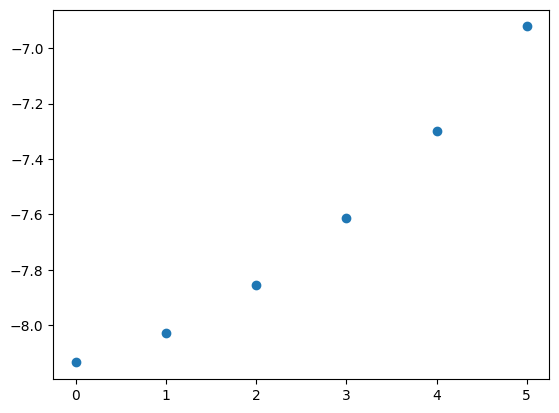

In [9]:
plt.scatter(np.arange(6),eigenvalues)

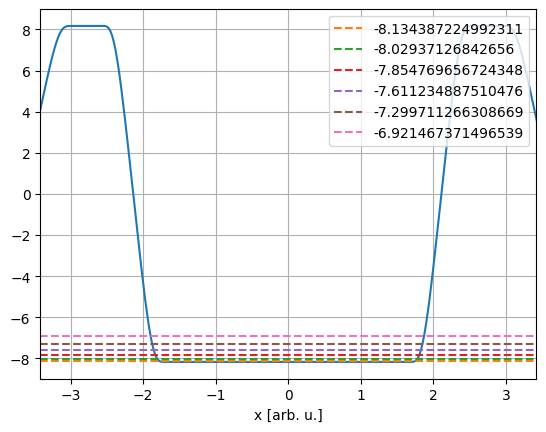

In [10]:
# plt.plot(uxgrid,modelpot(0),label="Pot")
# plt.plot(uxgrid,np.real(eigenvectors[:,0]),label="Re")
# plt.plot(uxgrid,np.imag(eigenvectors[:,0]),label="Im")
# plt.plot(uxgrid,np.abs(eigenvectors[:,0]),label="Abs")

plt.plot(uxgrid,modelpot(0))
for eval,evec  in zip(eigenvalues,np.transpose(eigenvectors)):
    plt.plot(uxgrid,eval*np.ones_like(uxgrid),"--",label=str(eval))
    #plt.plot(uxgrid,0.5*np.real(evec)+eval)#,label="Re")
    #plt.plot(uxgrid,0.5*np.imag(evec)+eval)#,label="Im")
    #plt.plot(uxgrid,np.abs(evec)**2+eval)#,label="Abs")
plt.xlabel("x [arb. u.]")
plt.xlim([-0.8*modelpot.wellwidth, 0.8*modelpot.wellwidth])
plt.legend(loc='upper right')
plt.grid()
plt.show()

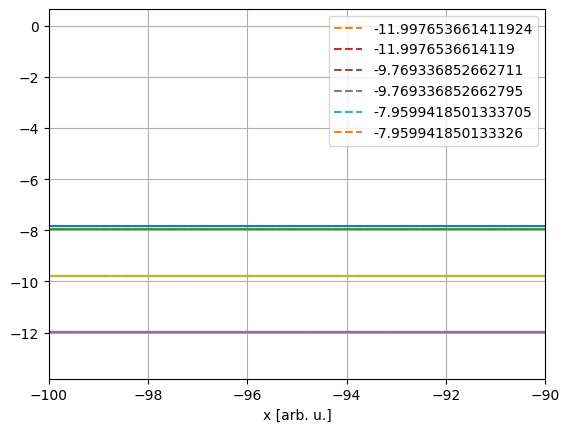

In [ ]:
plt.plot(uxgrid,modelpot(0))
for eval,evec  in zip(eigenvalues,np.transpose(eigenvectors)):
    plt.plot(uxgrid,eval*np.ones_like(uxgrid),"--",label=str(eval))
    #plt.plot(uxgrid,0.5*np.real(evec)+eval)#,label="Re")
    #plt.plot(uxgrid,0.5*np.imag(evec)+eval)#,label="Im")
    plt.plot(uxgrid,np.abs(evec)**2+eval)#,label="Abs")
plt.xlabel("x [arb. u.]")
plt.xlim([-0.8*modelpot.wellwidth, 0.8*modelpot.wellwidth])
#plt.ylim(-520000,-480000)
plt.xlim(-100,-90)
plt.legend(loc='upper right')
plt.grid()
plt.show()

In [ ]:
t_vals=[]
r_vals=[]

energy_min = 5.4
energy_max = 5.6

energy_min_in_unit_sys = energy_min*unit_sys.convert_energy_from('eV')
energy_max_in_unit_sys = energy_max*unit_sys.convert_energy_from('eV')

k_min = dispersion.energy2k(energy_min_in_unit_sys)
k_max = dispersion.energy2k(energy_max_in_unit_sys)

k_vals=np.linspace(k_min,k_max,11)

print(k_min,k_max,k_vals)

e_vals=[]

# quasiparticles=[]

# eigen_states_pk=[]
# eigen_states_mk=[]

quasiparticles_pk=[]
quasiparticles_mk=[]

for k in k_vals:

    kin=k
    ein=dispersion.k2energy(k)
    e_vals.append(ein)

    #inistate_pk, inistate_mk = getIniStates(Ein,uxgrid,modelpot)
    # state_pk_norm, state_mk_norm = trat.normed_states_at_given_energy(ein,kin,ham_static)
    # eigen_states_pk.append(state_pk_norm)
    # eigen_states_mk.append(state_mk_norm)

    qp_pk, qp_mk = quat.quasiparticles_at_given_energy(ein,kin,ham_static)
    quasiparticles_pk.append(qp_pk)
    quasiparticles_mk.append(qp_mk)

    #trans,refl = get_t_and_r(Ein,uxgrid,uxgrid_dx,inistate_pk)
    #trans,refl = trat.transmission(kin,state_pk_norm),trat.reflexion(kin,state_pk_norm)

    t_vals.append(qp_pk['transmission'])
    r_vals.append(qp_pk['reflection'])

    print(kin)

    num=len(t_vals)

    # plt.plot(k_vals[:num],t_vals,"-o",label="T")
    # plt.plot(k_vals[:num],r_vals,"-o",label="R")
    # plt.xlabel("k [arb. u.]")
    # #plt.ylabel("Coefficient")
    # plt.legend()
    # plt.grid()
    # plt.show()

30.826417833609003 31.545414342004676 [30.82641783 30.89831748 30.97021714 31.04211679 31.11401644 31.18591609
 31.25781574 31.32971539 31.40161504 31.47351469 31.54541434]


KeyboardInterrupt: 

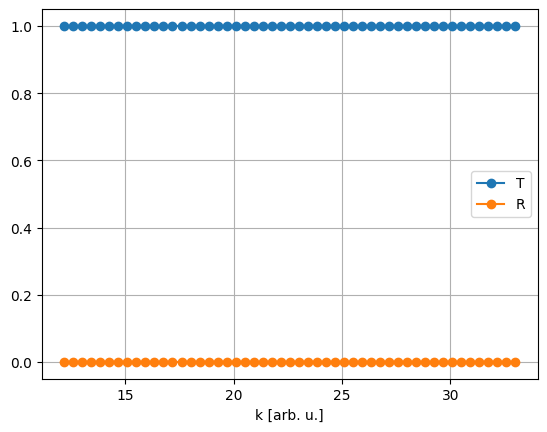

In [ ]:
plt.plot(k_vals,t_vals,"-o",label="T")
plt.plot(k_vals,r_vals,"-o",label="R")
plt.xlabel("k [arb. u.]")
#plt.ylabel("Coefficient")
plt.legend()
plt.grid()
plt.show()

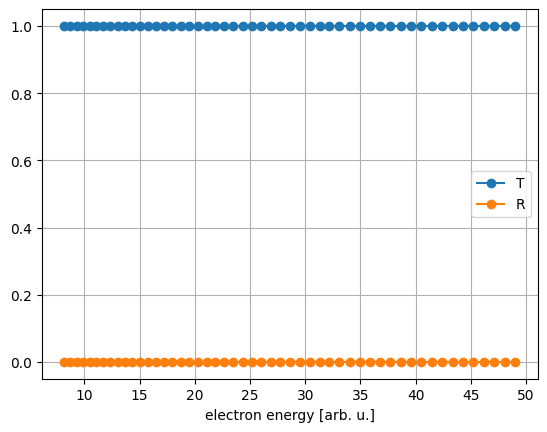

In [ ]:
plt.plot(e_vals,t_vals,"-o",label="T")
plt.plot(e_vals,r_vals,"-o",label="R")
plt.xlabel("electron energy [arb. u.]")
#plt.ylabel("Coefficient")
plt.legend()
plt.grid()
plt.show()

In [ ]:
t_vals=[]
r_vals=[]

energy_min = 1.0
energy_max = 6.0

energy_min_in_unit_sys = energy_min*unit_sys.convert_energy_from('eV')
energy_max_in_unit_sys = energy_max*unit_sys.convert_energy_from('eV')

k_min = dispersion.energy2k(energy_min_in_unit_sys)
k_max = dispersion.energy2k(energy_max_in_unit_sys)

k_vals=np.linspace(k_min,k_max,51)

print(k_min,k_max,k_vals)

e_vals=[]

# quasiparticles=[]

# eigen_states_pk=[]
# eigen_states_mk=[]

quasiparticles_pk=[]
quasiparticles_mk=[]

for k in k_vals:

    kin=k
    ein=dispersion.k2energy(k)
    e_vals.append(ein)

    #inistate_pk, inistate_mk = getIniStates(Ein,uxgrid,modelpot)
    # state_pk_norm, state_mk_norm = trat.normed_states_at_given_energy(ein,kin,ham_static)
    # eigen_states_pk.append(state_pk_norm)
    # eigen_states_mk.append(state_mk_norm)

    qp_pk, qp_mk = quat.quasiparticles_at_given_energy(ein,kin,ham_static)
    quasiparticles_pk.append(qp_pk)
    quasiparticles_mk.append(qp_mk)

    #trans,refl = get_t_and_r(Ein,uxgrid,uxgrid_dx,inistate_pk)
    #trans,refl = trat.transmission(kin,state_pk_norm),trat.reflexion(kin,state_pk_norm)

    t_vals.append(qp_pk['transmission'])
    r_vals.append(qp_pk['reflection'])

    print(kin)

12.178183144730632 32.98484255313284 [12.17818314 12.59431633 13.01044952 13.42658271 13.8427159  14.25884909
 14.67498227 15.09111546 15.50724865 15.92338184 16.33951503 16.75564821
 17.1717814  17.58791459 18.00404778 18.42018097 18.83631416 19.25244734
 19.66858053 20.08471372 20.50084691 20.9169801  21.33311328 21.74924647
 22.16537966 22.58151285 22.99764604 23.41377923 23.82991241 24.2460456
 24.66217879 25.07831198 25.49444517 25.91057835 26.32671154 26.74284473
 27.15897792 27.57511111 27.9912443  28.40737748 28.82351067 29.23964386
 29.65577705 30.07191024 30.48804342 30.90417661 31.3203098  31.73644299
 32.15257618 32.56870936 32.98484255]
0.038463353210253855 3.849512200341126e-05
12.178183144730632
0.03735682744230185 5.066864704255069e-05
12.594316332898677
0.0363274735444624 6.0266696088226224e-06
13.01044952106672
0.03536822580359018 6.9320188675169194e-06
13.426582709234765
0.03447287320376666 2.165760696051446e-05
13.842715897402808
0.03363593488586363 1.70714993973193

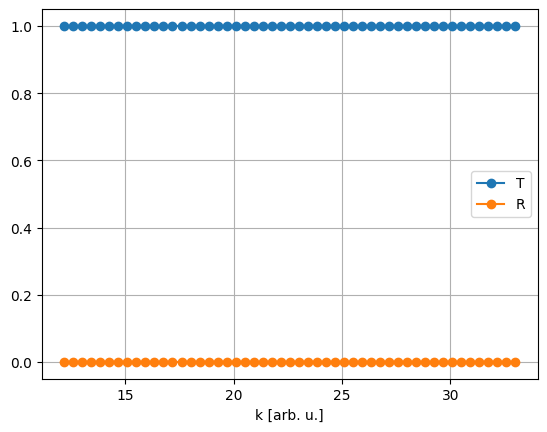

In [ ]:
plt.plot(k_vals,t_vals,"-o",label="T")
plt.plot(k_vals,r_vals,"-o",label="R")
plt.xlabel("k [arb. u.]")
#plt.ylabel("Coefficient")
plt.legend()
plt.grid()
plt.show()

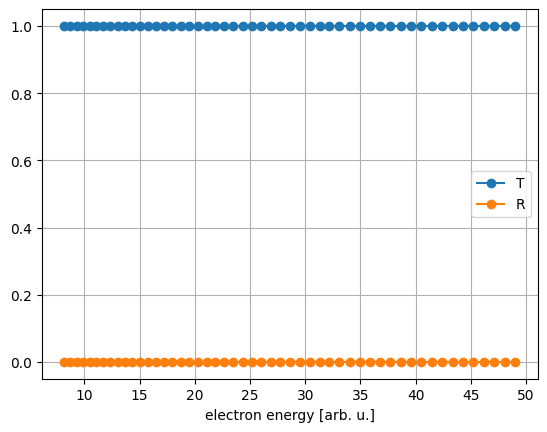

In [ ]:
plt.plot(e_vals,t_vals,"-o",label="T")
plt.plot(e_vals,r_vals,"-o",label="R")
plt.xlabel("electron energy [arb. u.]")
#plt.ylabel("Coefficient")
plt.legend()
plt.grid()
plt.show()

# Laser potential

In [ ]:
t_start=0
t_stop=1000.0
#t_num=10000

#utgrid=np.linspace(t_start,t_stop,t_num)
#utgrid_dt=utgrid[1]-utgrid[0]
utgrid_dt=0.05
utgrid=np.arange(t_start,t_stop,utgrid_dt)
t_num=len(utgrid)

#print(utgrid_dt)
print(t_num)

20000


In [ ]:
spot_size_nm = 800 # in nm
magnitude_of_electric_field_vm = 1.0 # in GV/m
central_wavelength_nm = 800 # in nm

In [ ]:
central_wavelength = central_wavelength_nm*unit_sys.convert_length_from("nm")
print(central_wavelength)

omega = 2*np.pi*unit_sys.speed_of_light/central_wavelength_nm
print(omega)
num_of_cycles = 5 # one cycle is around 2.66 fs

t_min = 0
t_max = num_of_cycles*2*np.pi/omega
print("pulse length hus:",t_max,t_max*unit_sys.time_unit.to("fs"))

s_min = -0.5*spot_size_nm*unit_sys.convert_length_from("nm")
s_max = 0.5*spot_size_nm*unit_sys.convert_length_from("nm")
print("spot size:",s_min,s_max)


magnitude = magnitude_of_electric_field_vm*unit_sys.convert_electric_field_from("GV/m")
print(magnitude)

beta=0.2

laserpot = pots.SmoothLaserPotential(uxgrid, spatial_min = s_min, spatial_max = s_max,\
                                            temporal_max=t_max,temporal_min=t_min,noc=num_of_cycles,\
                                            amplitude=magnitude,beta=beta)

laserpot_masked = pots.SmoothLaserPotential(uxgrid[mask], spatial_min = s_min, spatial_max = s_max,\
                                            temporal_max=t_max,temporal_min=t_min,noc=num_of_cycles,\
                                            amplitude=magnitude,beta=beta)

print(laserpot.omega0)

341.8032468253572
5.409467923108539
pulse length hus: 5.807581629552364 31.228641464002013 femtosecond
spot size: -170.9016234126786 170.9016234126786
5.623761413124601
5.409467923108539


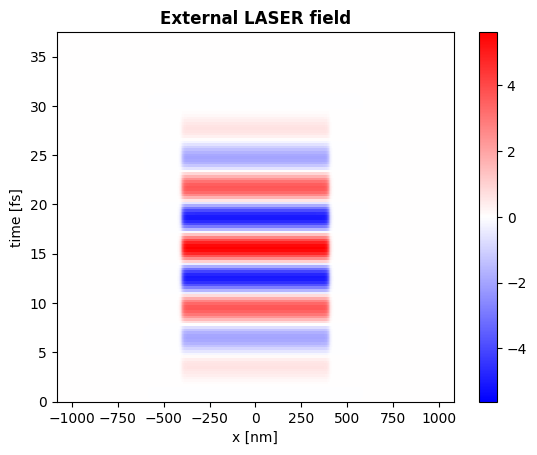

In [ ]:
X,Y = np.meshgrid(uxgrid[mask],utgrid)
X_nm,Y_fs = np.meshgrid(uxgrid[mask]*unit_sys.length_unit.to('nm').magnitude,\
                  utgrid*unit_sys.time_unit.to('fs').magnitude)

Z=laserpot_masked(Y)

z_min, z_max = -np.abs(Z).max(), np.abs(Z).max()
    
pcm = plt.pcolormesh(X_nm, Y_fs, Z, cmap ='bwr', vmin = z_min, vmax = z_max)
plt.colorbar(pcm)
 
plt.title('External LASER field', fontweight ="bold")
plt.ylim(0.0,1.2*laserpot.temporal_max*unit_sys.time_unit.to('fs').magnitude)
#plt.xlim(2*laserpot_cep0.spatial_min,2*laserpot_cep0.spatial_max)
plt.xlabel("x [nm]")
plt.ylabel("time [fs]")
plt.show()

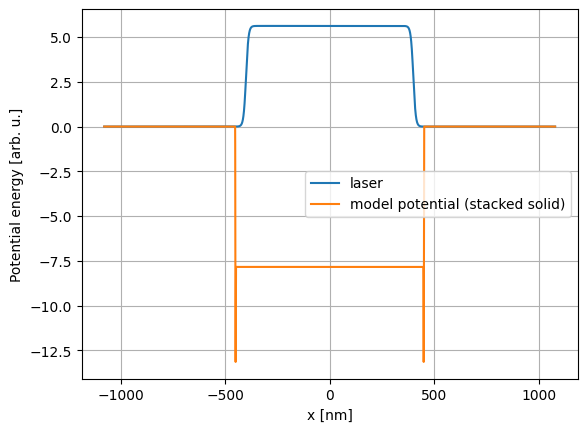

In [ ]:
plt.plot(uxgrid*unit_sys.length_unit.to("nm"),\
          laserpot(laserpot.temporal_width/2),label="laser")
plt.plot(uxgrid*unit_sys.length_unit.to("nm"),\
          modelpot(uxgrid),label="model potential (stacked solid)")
#plt.xlim([-0.8*modelpot.wellwidth, 0.8*modelpot.wellwidth])
plt.legend()
plt.xlabel("x [nm]")
plt.ylabel("Potential energy [arb. u.]")
plt.grid()
plt.show()

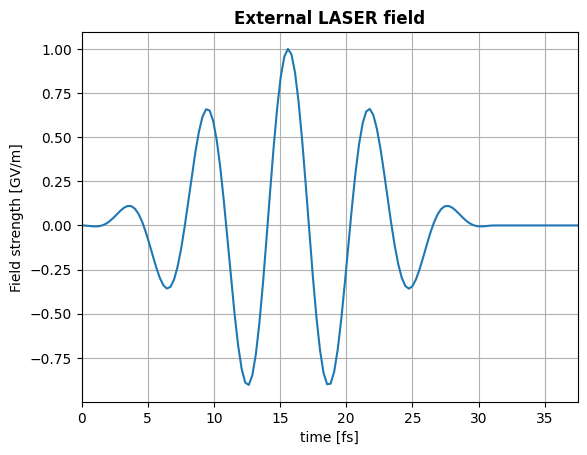

In [ ]:
plt.plot(utgrid*unit_sys.time_unit.to('fs').magnitude,\
          laserpot.value_at(0.0,utgrid)*unit_sys.electric_field_unit.to('GV/m'),\
          label="laser")
plt.xlabel("time [fs]")
plt.ylabel("Field strength [GV/m]")
plt.title('External LASER field', fontweight ="bold")
plt.xlim(0,1.2*laserpot.temporal_width*unit_sys.time_unit.to('fs').magnitude)
plt.grid()
plt.show()

# Vcap check

## Advanced methode

In [ ]:
from quantum_toolkit import quantum_transport_toolkit as trat

ein=3.0*unit_sys.convert_energy_from('eV')
print(ein)
kin=dispersion.energy2k(ein)
print(kin)

qppk, qpmk = trat.quasiparticles_at_given_energy(ein,kin,ham_static,normed=False)

24.508303857308633
21.837608491652393


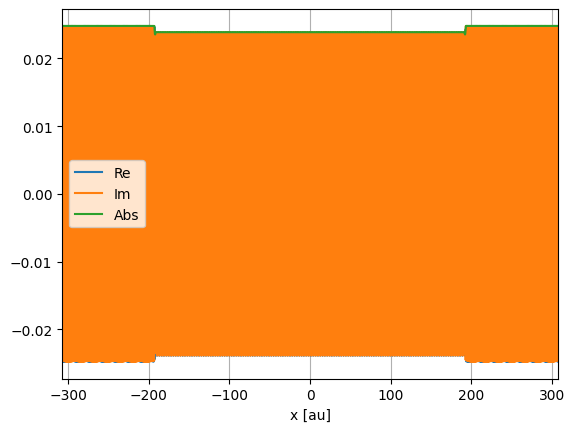

In [ ]:
#plt.plot(uxgrid,modelpot(0),label="Pot")
plt.plot(uxgrid,np.real(qppk["state"]["value"]),label="Re")
plt.plot(uxgrid,np.imag(qppk["state"]["value"]),label="Im")
plt.plot(uxgrid,np.abs(qppk["state"]["value"]),label="Abs")
plt.xlabel("x [au]")
plt.xlim([-0.8*modelpot.wellwidth, 0.8*modelpot.wellwidth])
plt.legend()
plt.grid()
plt.show()

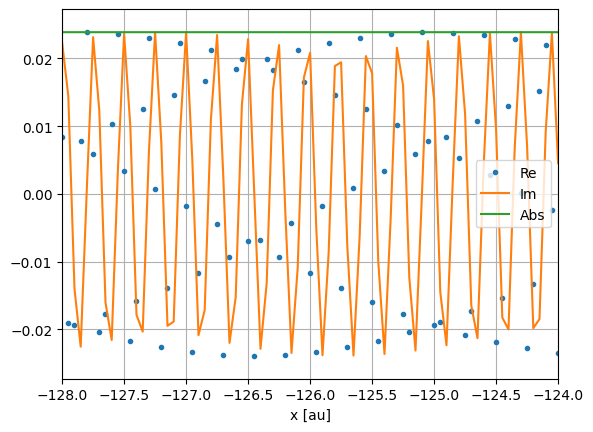

In [ ]:
#plt.plot(uxgrid,modelpot(0),label="Pot
plt.plot(uxgrid,np.real(qppk["state"]["value"]),'.',label="Re")
plt.plot(uxgrid,np.imag(qppk["state"]["value"]),label="Im")
plt.plot(uxgrid,np.abs(qppk["state"]["value"]),label="Abs")
plt.xlabel("x [au]")
plt.xlim([-128, -124])
plt.legend()
plt.grid()
plt.show()